### Trabalho Fase 1 do Curso de Pos-Graduacao FIAP IA para Devs
#### Parte 5 - Modelo Random Forest usando as bases preparadas

Fonte de dados escolhida: DATASUS/SISCAN  
Tipo de dados de origem nesta etapa: Parquet

Arquivos utilizados:

```text
bases/treino/x_encoded.parquet
bases/treino/y.parquet
bases/teste/x_encoded.parquet
bases/teste/y.parquet
```

---

## Objetivo da Parte 5

Treinar e avaliar um baseline Random Forest usando as bases encoded geradas na Parte 2, mantendo uma estrutura semelhante a Parte 4.

Diferente de KNN e SVM, Random Forest nao depende de distancia entre observacoes e, portanto, nao exige padronizacao ou normalizacao das features. Por isso, esta etapa compara apenas as duas representacoes de idade:

- idade com cap: `CO_IDADE_PACIENTE_CAP`;
- idade numerica sem cap: `CO_IDADE_PACIENTE_NUM`.

As variaveis categoricas ja codificadas em one-hot permanecem como `0/1`. O tuning com `GridSearchCV` refina hiperparametros da floresta e o tratamento de desbalanceamento via `class_weight`.

---

## Indice / Sumario da Parte 5

**Item 1 - Leitura e preparacao dos dados para Random Forest**

- Leitura das bases encoded, separacao das colunas de idade e das dummies categoricas.

**Item 2 - Amostragem estratificada para avaliacao inicial**

- Criacao de subconjuntos estratificados para comparacao dos cenarios e avaliacao.

**Item 3 - Comparacao dos cenarios de idade**

- Comparacao entre idade cap e idade num usando F1 e balanced accuracy.

**Item 4 - Tuning com GridSearchCV**

- Refinamento dos hiperparametros da Random Forest no melhor cenario de idade encontrado.

**Item 5 - Avaliacao detalhada da Random Forest tunada**

- Avaliacao do melhor estimador do GridSearchCV na amostra de teste.

**Item 6 - Conclusao da avaliacao Random Forest**

- Sintese comparativa dos cenarios, efeito do tuning, limitacoes observadas e recomendacao para proximas etapas.


#### Item 1 - Leitura e preparacao dos dados para Random Forest

A Parte 5 usa diretamente `x_encoded.parquet`, criado na Parte 2. Como a validacao das bases ja foi realizada na Parte 2, aqui apenas lemos os arquivos necessarios e definimos quais colunas entram em cada cenario da Random Forest.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42
TARGET_COLUMN = 'TARGET_CANCER_MAMA_PROVAVEL'
BASES_DIR = Path('bases')

N_TREINO_RF = 12000
N_VALIDACAO_RF = 4000
N_TESTE_RF = 8000

arquivos_entrada = {
    'x_treino_encoded': BASES_DIR / 'treino' / 'x_encoded.parquet',
    'y_treino': BASES_DIR / 'treino' / 'y.parquet',
    'x_teste_encoded': BASES_DIR / 'teste' / 'x_encoded.parquet',
    'y_teste': BASES_DIR / 'teste' / 'y.parquet',
}

X_train_encoded = pd.read_parquet(arquivos_entrada['x_treino_encoded'])
y_train = pd.read_parquet(arquivos_entrada['y_treino'])[TARGET_COLUMN]
X_test_encoded = pd.read_parquet(arquivos_entrada['x_teste_encoded'])
y_test = pd.read_parquet(arquivos_entrada['y_teste'])[TARGET_COLUMN]

colunas_idade = ['CO_IDADE_PACIENTE_NUM', 'CO_IDADE_PACIENTE_CAP']
colunas_numericas_contexto = [
    coluna for coluna in ['CO_TEMPO_MAMO_ANTERIOR_NUM']
    if coluna in X_train_encoded.columns
]
colunas_categoricas_encoded = [
    coluna for coluna in X_train_encoded.columns
    if coluna not in colunas_idade + colunas_numericas_contexto
]

resumo_entrada_rf = {
    'shape_x_treino_encoded': X_train_encoded.shape,
    'shape_x_teste_encoded': X_test_encoded.shape,
    'colunas_idade_comparadas': colunas_idade,
    'qtd_colunas_numericas_contexto': len(colunas_numericas_contexto),
    'colunas_numericas_contexto': colunas_numericas_contexto,
    'qtd_colunas_categoricas_encoded': len(colunas_categoricas_encoded),
}
resumo_entrada_rf


{'shape_x_treino_encoded': (213978, 24),
 'shape_x_teste_encoded': (53495, 24),
 'colunas_idade_comparadas': ['CO_IDADE_PACIENTE_NUM',
  'CO_IDADE_PACIENTE_CAP'],
 'qtd_colunas_categoricas_encoded': 22}

#### Item 2 - Amostragem estratificada para avaliacao inicial

A amostra e estratificada para preservar aproximadamente a proporcao da target. Os mesmos subconjuntos sao usados nos cenarios de idade para tornar a comparacao mais justa.


In [2]:
def limitar_amostra_estratificada(X, y, n_amostra, random_state=RANDOM_STATE):
    if n_amostra is None or n_amostra >= len(X):
        return X.copy(), y.copy()

    _, X_amostra, _, y_amostra = train_test_split(
        X,
        y,
        test_size=n_amostra,
        random_state=random_state,
        stratify=y,
    )
    return X_amostra.reset_index(drop=True), y_amostra.reset_index(drop=True)


X_train_amostra_total, y_train_amostra_total = limitar_amostra_estratificada(
    X_train_encoded,
    y_train,
    N_TREINO_RF + N_VALIDACAO_RF,
)

X_train_base_rf, X_valid_base_rf, y_train_rf, y_valid_rf = train_test_split(
    X_train_amostra_total,
    y_train_amostra_total,
    train_size=N_TREINO_RF,
    random_state=RANDOM_STATE,
    stratify=y_train_amostra_total,
)

X_test_base_rf, y_test_rf = limitar_amostra_estratificada(
    X_test_encoded,
    y_test,
    N_TESTE_RF,
)

amostras_rf = pd.DataFrame([
    {'base': 'treino_rf', 'linhas': len(X_train_base_rf), 'classe_positiva': int(y_train_rf.sum()), 'percentual_positivo': round(y_train_rf.mean() * 100, 2)},
    {'base': 'validacao_rf', 'linhas': len(X_valid_base_rf), 'classe_positiva': int(y_valid_rf.sum()), 'percentual_positivo': round(y_valid_rf.mean() * 100, 2)},
    {'base': 'teste_rf', 'linhas': len(X_test_base_rf), 'classe_positiva': int(y_test_rf.sum()), 'percentual_positivo': round(y_test_rf.mean() * 100, 2)},
])
amostras_rf


,base,linhas,classe_positiva,percentual_positivo
0,treino_rf,12000,509,4.24
1,validacao_rf,4000,170,4.25
2,teste_rf,8000,339,4.24


#### Item 3 - Comparacao dos cenarios de idade

Cada cenario usa uma unica coluna de idade (`NUM` ou `CAP`) e mantem as demais dummies categoricas como `0/1`. Nao ha padronizacao nem normalizacao, pois Random Forest nao depende de distancia euclidiana.


In [3]:
def selecionar_features_cenario(df, coluna_idade):
    colunas_modelo = [coluna_idade] + colunas_numericas_contexto + colunas_categoricas_encoded
    df_modelo = df[colunas_modelo].copy()
    for coluna in [coluna_idade] + colunas_numericas_contexto:
        df_modelo[coluna] = pd.to_numeric(df_modelo[coluna], errors='coerce')
    return df_modelo


def criar_modelo_rf(n_estimators=200, max_depth=None, min_samples_leaf=1, class_weight='balanced'):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


cenarios_idade = [
    {'coluna_idade': 'CO_IDADE_PACIENTE_CAP', 'idade': 'cap'},
    {'coluna_idade': 'CO_IDADE_PACIENTE_NUM', 'idade': 'num'},
]

parametros_rf_iniciais = [
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced'},
    {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 5, 'class_weight': 'balanced'},
    {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'class_weight': 'balanced'},
    {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 10, 'class_weight': 'balanced_subsample'},
]

resultados_busca = []
modelos_avaliados = {}

for cenario in cenarios_idade:
    X_train_cenario = selecionar_features_cenario(X_train_base_rf, cenario['coluna_idade'])
    X_valid_cenario = selecionar_features_cenario(X_valid_base_rf, cenario['coluna_idade'])

    for params in parametros_rf_iniciais:
        modelo = criar_modelo_rf(**params)
        modelo.fit(X_train_cenario, y_train_rf)
        y_pred_valid = modelo.predict(X_valid_cenario)

        chave = (
            f"idade={cenario['idade']}, n_estimators={params['n_estimators']}, "
            f"max_depth={params['max_depth']}, min_samples_leaf={params['min_samples_leaf']}, "
            f"class_weight={params['class_weight']}"
        )
        modelos_avaliados[chave] = {
            'modelo': modelo,
            'coluna_idade': cenario['coluna_idade'],
            'idade': cenario['idade'],
        }
        resultados_busca.append({
            'modelo': chave,
            'idade': cenario['idade'],
            'coluna_idade': cenario['coluna_idade'],
            **params,
            'accuracy': round(accuracy_score(y_valid_rf, y_pred_valid), 4),
            'balanced_accuracy': round(balanced_accuracy_score(y_valid_rf, y_pred_valid), 4),
            'precision': round(precision_score(y_valid_rf, y_pred_valid, zero_division=0), 4),
            'recall': round(recall_score(y_valid_rf, y_pred_valid, zero_division=0), 4),
            'f1': round(f1_score(y_valid_rf, y_pred_valid, zero_division=0), 4),
        })

resultados_busca_rf = pd.DataFrame(resultados_busca).sort_values(
    ['f1', 'balanced_accuracy'],
    ascending=False,
).reset_index(drop=True)

comparacao_cenarios_rf = (
    resultados_busca_rf
    .sort_values(['f1', 'balanced_accuracy'], ascending=False)
    .groupby(['idade'], as_index=False)
    .first()
    .sort_values(['f1', 'balanced_accuracy'], ascending=False)
    .reset_index(drop=True)
)

comparacao_cenarios_rf


,idade,modelo,coluna_idade,n_estimators,max_depth,min_samples_leaf,class_weight,accuracy,balanced_accuracy,precision,recall,f1
0,num,"idade=num, n_estimators=200, max_depth=12, min...",CO_IDADE_PACIENTE_NUM,200,12.0,5,balanced,0.792,0.5682,0.0712,0.3235,0.1168
1,cap,"idade=cap, n_estimators=200, max_depth=12, min...",CO_IDADE_PACIENTE_CAP,200,12.0,10,balanced_subsample,0.775,0.5677,0.0686,0.3412,0.1142


#### Item 4 - Tuning com GridSearchCV

Depois da comparacao inicial entre idade cap/num, o tuning abaixo usa o melhor tipo de idade encontrado e aplica `GridSearchCV` para refinar os hiperparametros da Random Forest.


In [4]:
melhor_coluna_idade_grid = comparacao_cenarios_rf.loc[0, 'coluna_idade']
X_train_grid = selecionar_features_cenario(X_train_base_rf, melhor_coluna_idade_grid)

modelo_grid = criar_modelo_rf()

param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample'],
}

cv_rf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search_rf = GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=cv_rf,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_search_rf.fit(X_train_grid, y_train_rf)

resultados_grid_rf = pd.DataFrame(grid_search_rf.cv_results_).sort_values(
    'rank_test_score',
).reset_index(drop=True)

colunas_resultado_grid = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_leaf',
    'param_class_weight',
]

resultados_grid_rf[colunas_resultado_grid].head(10)


/Users/igorcarletti/Development/workspace/trabalho2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/igorcarletti/Development/workspace/trabalho2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/igorcarletti/Development/workspace/trabalho2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_min_samples_leaf,param_class_weight
0,1,0.125142,0.013916,0.219623,200,None,10,balanced_subsample
1,2,0.124808,0.010011,0.219100,200,None,10,balanced
2,3,0.123972,0.008035,0.196140,200,12,10,balanced
3,4,0.122560,0.008191,0.194868,200,12,10,balanced_subsample
4,5,0.122415,0.014159,0.169380,200,8,10,balanced_subsample
5,6,0.120213,0.011728,0.173011,200,8,10,balanced
6,7,0.120108,0.005830,0.226917,200,12,5,balanced
7,8,0.118368,0.002580,0.224653,200,12,5,balanced_subsample
8,9,0.118008,0.004912,0.250787,200,None,5,balanced
9,10,0.117871,0.014302,0.179070,200,8,5,balanced_subsample


In [5]:
melhor_modelo_rf = grid_search_rf.best_estimator_
melhor_modelo_info = {
    'modelo': melhor_modelo_rf,
    'coluna_idade': melhor_coluna_idade_grid,
    'idade': comparacao_cenarios_rf.loc[0, 'idade'],
}

resumo_grid_search_rf = {
    'melhor_coluna_idade': melhor_coluna_idade_grid,
    'melhores_parametros': grid_search_rf.best_params_,
    'melhor_f1_cv': round(grid_search_rf.best_score_, 4),
}

resumo_grid_search_rf


{'melhor_coluna_idade': 'CO_IDADE_PACIENTE_NUM',
 'melhores_parametros': {'class_weight': 'balanced_subsample',
  'max_depth': None,
  'min_samples_leaf': 10,
  'n_estimators': 200},
 'melhor_f1_cv': np.float64(0.1251)}

#### Item 5 - Avaliacao detalhada da Random Forest tunada

O melhor estimador do `GridSearchCV` e avaliado na amostra estratificada de teste. As metricas devem ser interpretadas como baseline inicial, nao como resultado final de modelagem.


In [6]:
X_test_rf = selecionar_features_cenario(
    X_test_base_rf,
    melhor_modelo_info['coluna_idade'],
)

y_pred_test = melhor_modelo_rf.predict(X_test_rf)
y_score_test = melhor_modelo_rf.predict_proba(X_test_rf)[:, 1]

metricas_teste_rf = {
    'modelo': 'GridSearchCV RandomForestClassifier',
    'melhores_parametros': str(grid_search_rf.best_params_),
    'melhor_f1_cv': round(grid_search_rf.best_score_, 4),
    'idade': melhor_modelo_info['idade'],
    'coluna_idade': melhor_modelo_info['coluna_idade'],
    'linhas_treino_usadas': len(X_train_base_rf),
    'linhas_teste_avaliadas': len(X_test_base_rf),
    'accuracy': round(accuracy_score(y_test_rf, y_pred_test), 4),
    'balanced_accuracy': round(balanced_accuracy_score(y_test_rf, y_pred_test), 4),
    'precision': round(precision_score(y_test_rf, y_pred_test, zero_division=0), 4),
    'recall': round(recall_score(y_test_rf, y_pred_test, zero_division=0), 4),
    'f1': round(f1_score(y_test_rf, y_pred_test, zero_division=0), 4),
    'roc_auc': round(roc_auc_score(y_test_rf, y_score_test), 4),
}

metricas_teste_rf


{'modelo': 'GridSearchCV RandomForestClassifier',
 'melhores_parametros': "{'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}",
 'melhor_f1_cv': np.float64(0.1251),
 'idade': 'num',
 'coluna_idade': 'CO_IDADE_PACIENTE_NUM',
 'linhas_treino_usadas': 12000,
 'linhas_teste_avaliadas': 8000,
 'accuracy': 0.7971,
 'balanced_accuracy': 0.5924,
 'precision': 0.0815,
 'recall': 0.3687,
 'f1': 0.1335,
 'roc_auc': 0.6248}

In [7]:
relatorio_classificacao_rf = pd.DataFrame(
    classification_report(
        y_test_rf,
        y_pred_test,
        output_dict=True,
        zero_division=0,
    )
).T
relatorio_classificacao_rf


,precision,recall,f1-score,support
0,0.966904,0.816081,0.885114,7661.000000
1,0.081486,0.368732,0.133476,339.000000
accuracy,0.797125,0.797125,0.797125,0.797125
macro avg,0.524195,0.592407,0.509295,8000.000000
weighted avg,0.929384,0.797125,0.853263,8000.000000


In [8]:
matriz_confusao_rf = pd.DataFrame(
    confusion_matrix(y_test_rf, y_pred_test),
    index=['real_0', 'real_1'],
    columns=['pred_0', 'pred_1'],
)
matriz_confusao_rf


,pred_0,pred_1
real_0,6252,1409
real_1,214,125


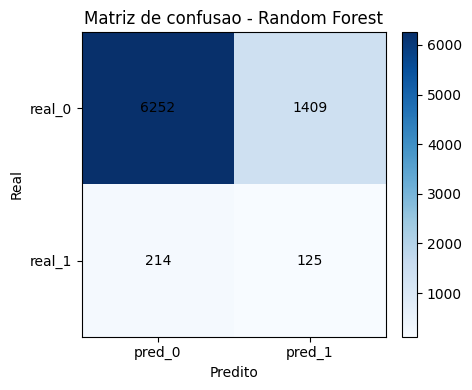

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_confusao_rf.values, cmap='Blues')
ax.set_xticks(range(2), matriz_confusao_rf.columns)
ax.set_yticks(range(2), matriz_confusao_rf.index)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusao - Random Forest')

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_confusao_rf.iloc[i, j], ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [10]:
importancias_rf = pd.DataFrame({
    'feature': X_test_rf.columns,
    'importancia': melhor_modelo_rf.feature_importances_,
}).sort_values('importancia', ascending=False).reset_index(drop=True)

importancias_rf.head(15)


,feature,importancia
0,CO_IDADE_PACIENTE_NUM,0.438492
1,CO_IND_CLINICA_02,0.109233
2,CO_IND_CLINICA_01,0.092566
3,TP_MAMOGRAFIA_RASTREAMENT_01,0.058623
4,TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ_01,0.034699
5,CO_RACA_COR_04,0.028757
6,CO_RACA_COR_03,0.025467
7,CO_RACA_COR_01,0.024582
8,TP_RESP_ANT_MAMA_EXA_PROF_SAUD_01,0.023426
9,TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ_02,0.021472


#### Item 6 - Conclusao da avaliacao Random Forest

A conclusao abaixo compara os cenarios de idade, sintetiza o tuning com GridSearchCV e as principais metricas da Random Forest tunada. Esta etapa nao exporta arquivos; os resultados permanecem documentados no notebook.


In [11]:
melhor_cenario = comparacao_cenarios_rf.iloc[0]
segundo_cenario = comparacao_cenarios_rf.iloc[1]

conclusao_rf = pd.DataFrame([
    {
        'aspecto': 'melhor_cenario_validacao',
        'conclusao': f"idade={melhor_cenario['idade']}, max_depth={melhor_cenario['max_depth']}, min_samples_leaf={melhor_cenario['min_samples_leaf']}, class_weight={melhor_cenario['class_weight']}",
    },
    {
        'aspecto': 'comparacao_idade',
        'conclusao': f"Melhor F1 de validacao={melhor_cenario['f1']} contra {segundo_cenario['f1']} do outro cenario de idade ({segundo_cenario['idade']}).",
    },
    {
        'aspecto': 'tuning_gridsearch',
        'conclusao': f"Melhor F1 medio no CV={metricas_teste_rf['melhor_f1_cv']} com parametros {metricas_teste_rf['melhores_parametros']}",
    },
    {
        'aspecto': 'amostra_utilizada',
        'conclusao': f"{metricas_teste_rf['linhas_treino_usadas']} registros de treino e {metricas_teste_rf['linhas_teste_avaliadas']} registros de teste",
    },
    {
        'aspecto': 'desempenho_teste',
        'conclusao': f"accuracy={metricas_teste_rf['accuracy']}, balanced_accuracy={metricas_teste_rf['balanced_accuracy']}, roc_auc={metricas_teste_rf['roc_auc']}",
    },
    {
        'aspecto': 'classe_positiva',
        'conclusao': f"precision={metricas_teste_rf['precision']}, recall={metricas_teste_rf['recall']} e f1={metricas_teste_rf['f1']}",
    },
    {
        'aspecto': 'interpretacao',
        'conclusao': 'Random Forest nao exige escala e pode capturar interacoes nao lineares, mas ainda precisa lidar com o forte desbalanceamento da target.',
    },
    {
        'aspecto': 'decisao',
        'conclusao': 'A Random Forest deve ser comparada aos baselines KNN e SVM e pode servir como candidato mais adequado para dados tabulares.',
    },
    {
        'aspecto': 'proximos_passos',
        'conclusao': 'Avaliar threshold, calibracao de probabilidades, boosting e validacao mais ampla para reduzir variancia da amostragem.',
    },
])


class TabelaHTML(str):
    def _repr_html_(self):
        return str(self)

estilo_tabela_conclusao = '''
<style>
.tabela-conclusao-rf {
    width: 100%;
    table-layout: fixed;
    border-collapse: collapse;
}
.tabela-conclusao-rf th,
.tabela-conclusao-rf td {
    text-align: left;
    vertical-align: top;
    white-space: normal;
    word-wrap: break-word;
    overflow-wrap: anywhere;
    font-size: 13px;
    line-height: 1.35;
    padding: 8px 10px;
}
.tabela-conclusao-rf th:first-child,
.tabela-conclusao-rf td:first-child {
    width: 22%;
    font-weight: 600;
}
.tabela-conclusao-rf th:nth-child(2),
.tabela-conclusao-rf td:nth-child(2) {
    width: 78%;
}
</style>
'''

tabela_conclusao_html = conclusao_rf.to_html(
    index=False,
    escape=True,
    classes='tabela-conclusao-rf',
)

TabelaHTML(estilo_tabela_conclusao + tabela_conclusao_html)


aspecto,conclusao
melhor_cenario_validacao,"idade=num, max_depth=12.0, min_samples_leaf=5, class_weight=balanced"
comparacao_idade,Melhor F1 de validacao=0.1168 contra 0.1142 do outro cenario de idade (cap).
tuning_gridsearch,"Melhor F1 medio no CV=0.1251 com parametros {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}"
amostra_utilizada,12000 registros de treino e 8000 registros de teste
desempenho_teste,"accuracy=0.7971, balanced_accuracy=0.5924, roc_auc=0.6248"
classe_positiva,"precision=0.0815, recall=0.3687 e f1=0.1335"
interpretacao,"Random Forest nao exige escala e pode capturar interacoes nao lineares, mas ainda precisa lidar com o forte desbalanceamento da target."
decisao,A Random Forest deve ser comparada aos baselines KNN e SVM e pode servir como candidato mais adequado para dados tabulares.
proximos_passos,"Avaliar threshold, calibracao de probabilidades, boosting e validacao mais ampla para reduzir variancia da amostragem."


---

## Resultado da Parte 5

Este notebook treina e avalia um baseline Random Forest usando as bases encoded finais da Parte 2:

```text
bases/treino/x_encoded.parquet
bases/treino/y.parquet
bases/teste/x_encoded.parquet
bases/teste/y.parquet
```

A Parte 5 compara `CO_IDADE_PACIENTE_CAP` e `CO_IDADE_PACIENTE_NUM`. Diferente de KNN e SVM, nao aplica padronizacao nem normalizacao, pois Random Forest nao depende de distancia entre observacoes.

A avaliacao compara os cenarios por F1 e balanced accuracy na validacao, refina o melhor cenario com GridSearchCV e depois avalia o estimador tunado na amostra de teste.

Conclusao: a Random Forest fica registrada como baseline de modelo de arvores para comparacao com KNN e SVM. A comparacao entre idade cap/num e tuning com GridSearchCV ajuda a documentar a sensibilidade do modelo a representacao da idade, profundidade das arvores, folhas minimas e tratamento do desbalanceamento.
